# Análisis exploratorio de datos (EDA) - Airbnb Nueva York

## Objetivo

En este proyecto se realiza un análisis exploratorio de los datos de Airbnb en Nueva York del año 2019.

El objetivo es entender las variables del dataset, encontrar relaciones entre ellas y preparar los datos para futuros modelos de Machine Learning.

## Dataset

El dataset contiene información sobre alojamientos de Airbnb en Nueva York, incluyendo precio, tipo de habitación, número de reseñas y disponibilidad.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 1: Cargar los datos

In [3]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"

total_data = pd.read_csv(url)

total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Se cargan los datos y se visualizan las primeras filas para entender la estructura del dataset.

In [4]:
import os

os.makedirs("../data/raw", exist_ok=True)


total_data.to_csv("../data/raw/total_data.csv", index=False)

Los datos originales se guardan en la carpeta `data/raw` para mantener una copia del dataset sin modificar.

## Paso 2: Exploración inicial de los datos

In [5]:
total_data.shape

(48895, 16)

El dataset contiene el número de filas y columnas que vemos arriba.  
Esto nos da una idea del tamaño del conjunto de datos.

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

Aquí podemos ver el tipo de cada variable y si existen valores nulos en el dataset.

In [7]:
total_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Las estadísticas descriptivas nos permiten entender mejor variables como precio, número de reseñas o noches mínimas.

### Valores faltantes

In [8]:
total_data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Observamos que algunas variables tienen valores faltantes, especialmente `last_review` y `reviews_per_month`.

### Registros duplicados

In [9]:
print("Duplicados en name:", total_data["name"].duplicated().sum())
print("Duplicados en host_id:", total_data["host_id"].duplicated().sum())
print("Duplicados en id:", total_data["id"].duplicated().sum())

Duplicados en name: 989
Duplicados en host_id: 11438
Duplicados en id: 0


Algunas columnas pueden tener valores repetidos.  
Sin embargo, la columna `id` debería ser única para cada registro.

### Eliminación de columnas irrelevantes

In [10]:
total_data.drop(["id", "name", "host_name", "last_review", "reviews_per_month"], axis=1, inplace=True)

total_data.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


Se eliminan algunas columnas que no aportan información relevante para el análisis.

## Paso 3: Análisis de variables univariadas

En este paso analizamos cada variable del dataset de forma individual para entender su distribución y comportamiento.

### Variables categóricas

/tmp/ipykernel_2922/3530737518.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0,1].set_xticklabels(axis[0,1].get_xticklabels(), rotation=45)
/tmp/ipykernel_2922/3530737518.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0,2].set_xticklabels(axis[0,2].get_xticklabels(), rotation=90)


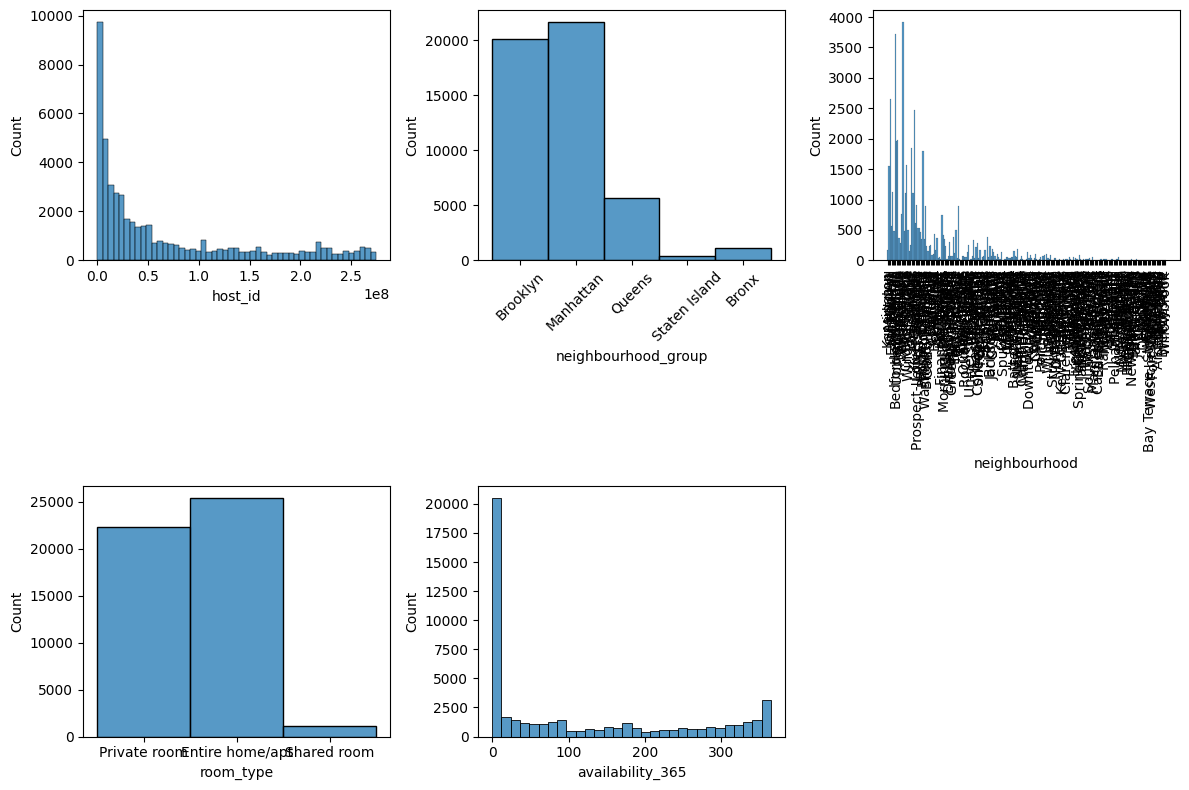

In [11]:
fig, axis = plt.subplots(2, 3, figsize=(12,8))

sns.histplot(ax=axis[0,0], data=total_data, x="host_id")

sns.histplot(ax=axis[0,1], data=total_data, x="neighbourhood_group")
axis[0,1].set_xticklabels(axis[0,1].get_xticklabels(), rotation=45)

sns.histplot(ax=axis[0,2], data=total_data, x="neighbourhood")
axis[0,2].set_xticklabels(axis[0,2].get_xticklabels(), rotation=90)

sns.histplot(ax=axis[1,0], data=total_data, x="room_type")

sns.histplot(ax=axis[1,1], data=total_data, x="availability_365")

fig.delaxes(axis[1,2])

plt.tight_layout()
plt.show()

Observaciones:

- Existen anfitriones con múltiples alojamientos registrados.
- Manhattan y Brooklyn concentran la mayoría de los alojamientos.
- La mayoría de los anuncios corresponden a **casas o apartamentos completos**.
- Las habitaciones compartidas son las menos comunes.
- Muchos alojamientos tienen disponibilidad durante gran parte del año.

### Variables numéricas

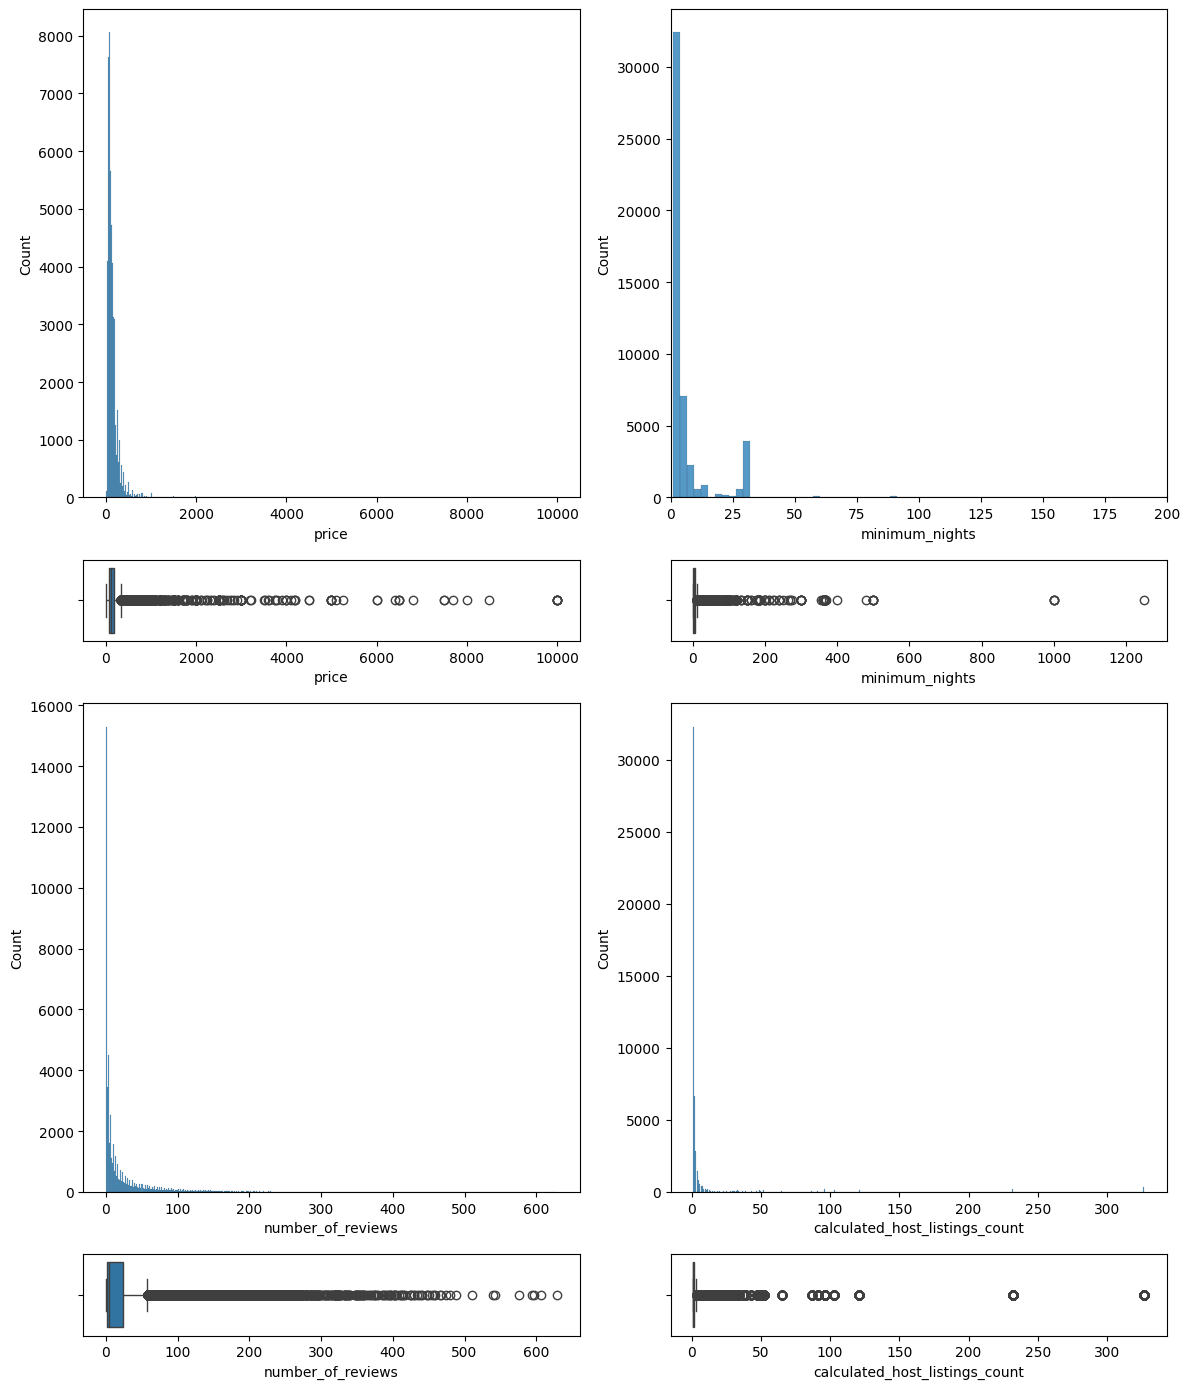

In [12]:
fig, axis = plt.subplots(4,2, figsize=(12,14), gridspec_kw={"height_ratios":[6,1,6,1]})

sns.histplot(ax=axis[0,0], data=total_data, x="price")
sns.boxplot(ax=axis[1,0], data=total_data, x="price")

sns.histplot(ax=axis[0,1], data=total_data, x="minimum_nights").set_xlim(0,200)
sns.boxplot(ax=axis[1,1], data=total_data, x="minimum_nights")

sns.histplot(ax=axis[2,0], data=total_data, x="number_of_reviews")
sns.boxplot(ax=axis[3,0], data=total_data, x="number_of_reviews")

sns.histplot(ax=axis[2,1], data=total_data, x="calculated_host_listings_count")
sns.boxplot(ax=axis[3,1], data=total_data, x="calculated_host_listings_count")

plt.tight_layout()
plt.show()

Observaciones:

- La variable price presenta una distribución muy asimétrica, con algunos precios extremadamente altos.
- La mayoría de las reservas tienen pocas noches mínimas requeridas
- El número de reseñas está concentrado en valores bajos.
- Algunos anfitriones poseen múltiples alojamientos registrados en la plataforma.

## Paso 4: Análisis de variables multivariadas

En este paso analizamos la relación entre diferentes variables del dataset para identificar posibles correlaciones o patrones.

### Relación entre variables numéricas

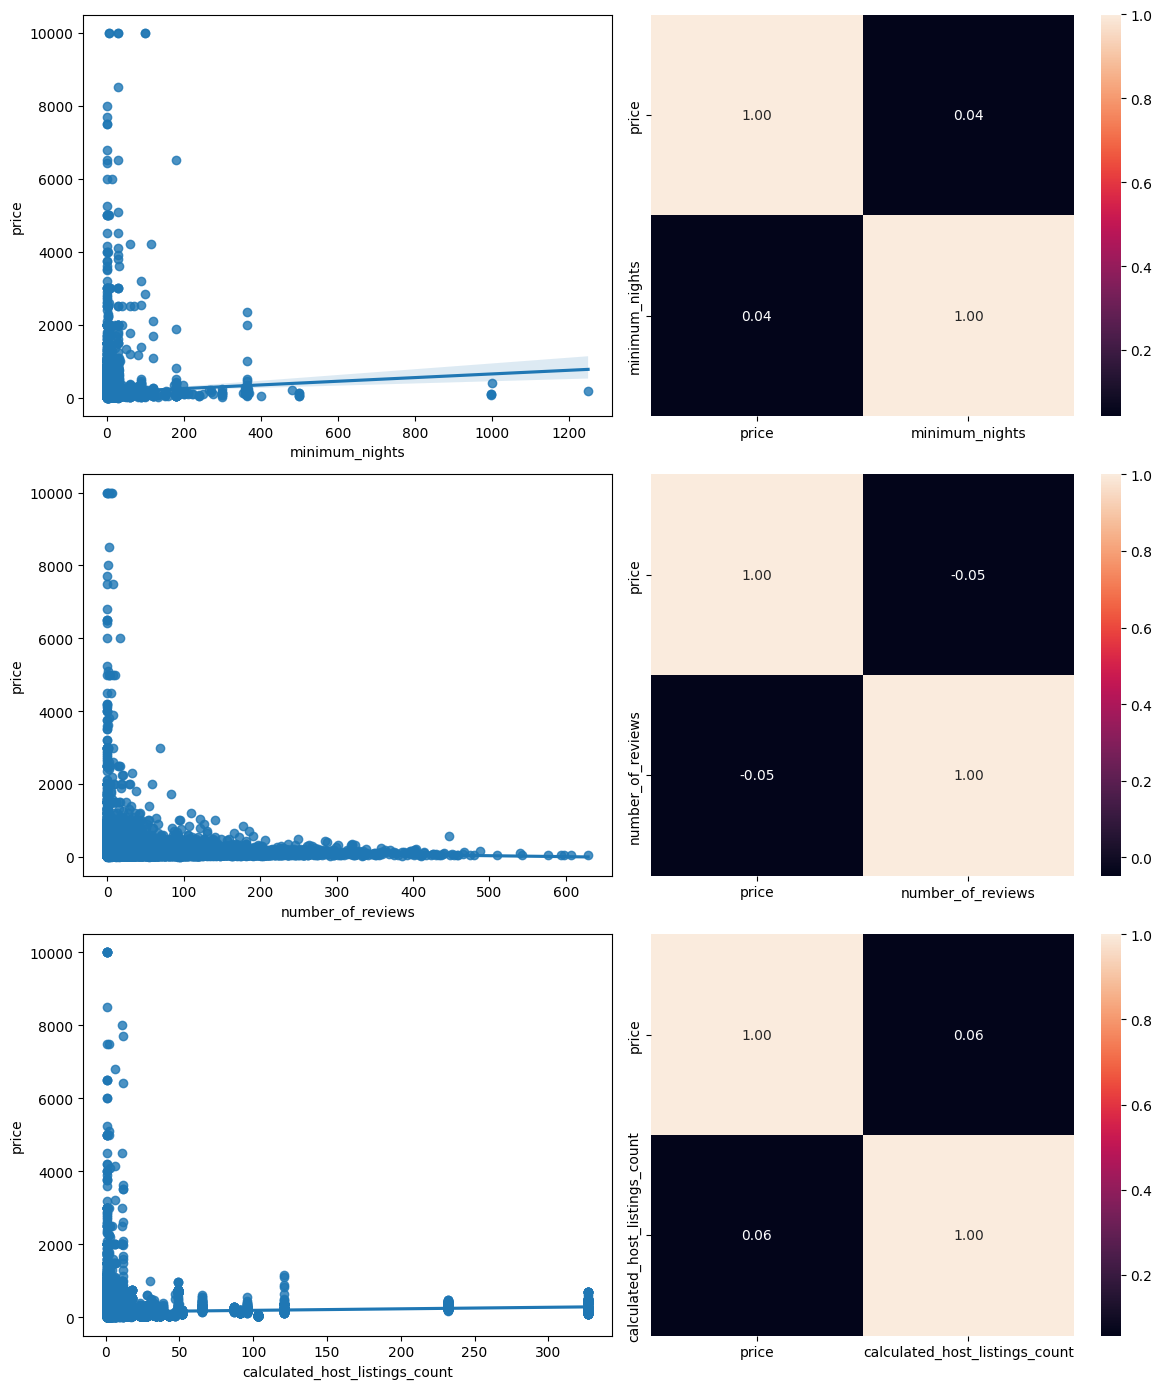

In [13]:
fig, axis = plt.subplots(3,2, figsize=(12,14))

sns.regplot(ax=axis[0,0], data=total_data, x="minimum_nights", y="price")
sns.heatmap(total_data[["price","minimum_nights"]].corr(), annot=True, fmt=".2f", ax=axis[0,1])

sns.regplot(ax=axis[1,0], data=total_data, x="number_of_reviews", y="price")
sns.heatmap(total_data[["price","number_of_reviews"]].corr(), annot=True, fmt=".2f", ax=axis[1,1])

sns.regplot(ax=axis[2,0], data=total_data, x="calculated_host_listings_count", y="price")
sns.heatmap(total_data[["price","calculated_host_listings_count"]].corr(), annot=True, fmt=".2f", ax=axis[2,1])

plt.tight_layout()
plt.show()

Observaciones:

- No se observa una relación fuerte entre el precio y el número mínimo de noches.
- Tampoco existe una correlación significativa entre el número de reseñas y el precio.
- Los anfitriones con más anuncios no necesariamente tienen precios más altos.

### Relación entre variables categóricas

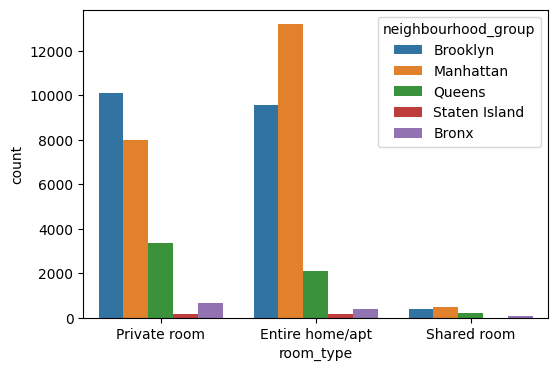

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=total_data, x="room_type", hue="neighbourhood_group")

plt.show()

Observaciones:

- Manhattan es el distrito con mayor número de alojamientos.
- Brooklyn ocupa el segundo lugar en número de propiedades.
- La mayoría de los alojamientos corresponden a casas o apartamentos completos.
- Las habitaciones compartidas representan una pequeña proporción del total.

### Matriz de correlación

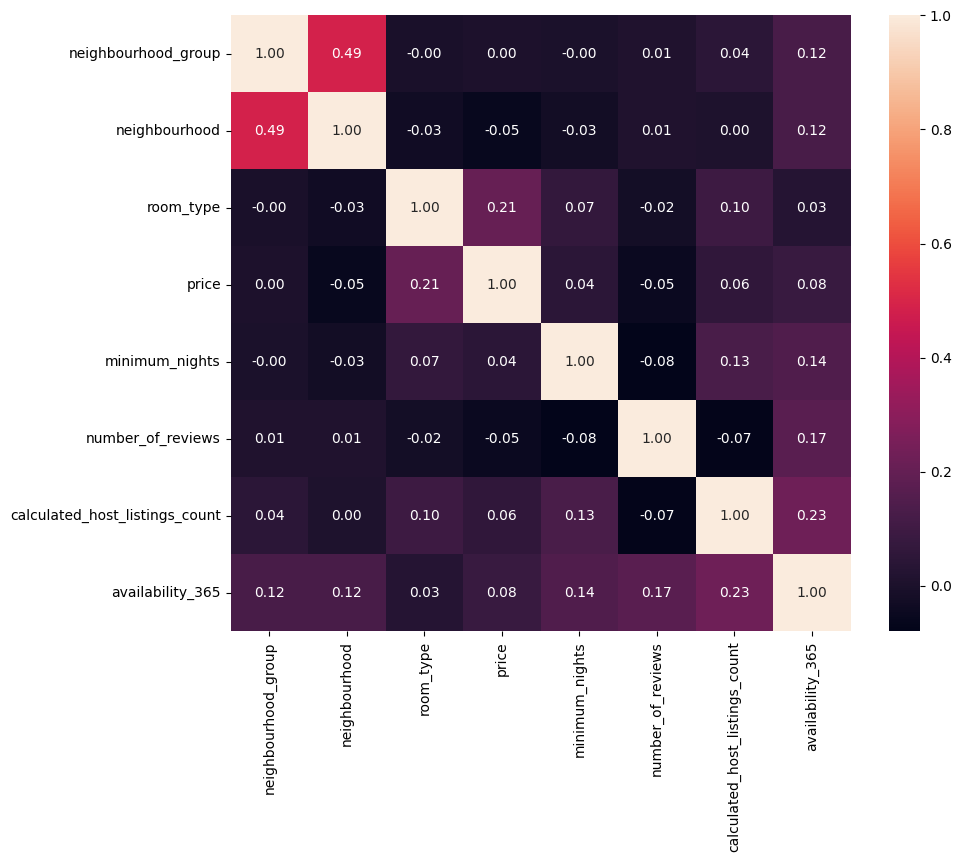

In [15]:
# Convertimos variables categóricas en numéricas

total_data["room_type"] = pd.factorize(total_data["room_type"])[0]
total_data["neighbourhood_group"] = pd.factorize(total_data["neighbourhood_group"])[0]
total_data["neighbourhood"] = pd.factorize(total_data["neighbourhood"])[0]

plt.figure(figsize=(10,8))

sns.heatmap(
    total_data[[
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "calculated_host_listings_count",
        "availability_365"
    ]].corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

Observaciones:

La matriz de correlación muestra que la mayoría de las variables presentan relaciones débiles entre sí.

La única relación ligeramente visible es entre el número de anuncios de un anfitrión y la disponibilidad del alojamiento.

## Paso 5: Detección de valores atípicos

En este paso analizamos posibles valores extremos dentro de las variables numéricas para identificar errores o valores poco representativos que puedan afectar el análisis o futuros modelos de Machine Learning.

In [16]:
total_data.describe()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,0.786911,29.888782,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,7.143982,112.781327
std,7.861097e+07,0.844386,34.676634,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,32.952519,131.622289
min,2.438000e+03,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,7.822033e+06,0.000000,7.500000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,1.000000,0.000000
50%,3.079382e+07,1.000000,19.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.074344e+08,1.000000,37.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.000000,227.000000
max,2.743213e+08,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,327.000000,365.000000


Las estadísticas descriptivas nos ayudan a identificar posibles valores extremos en variables como precio, noches mínimas o número de reseñas.

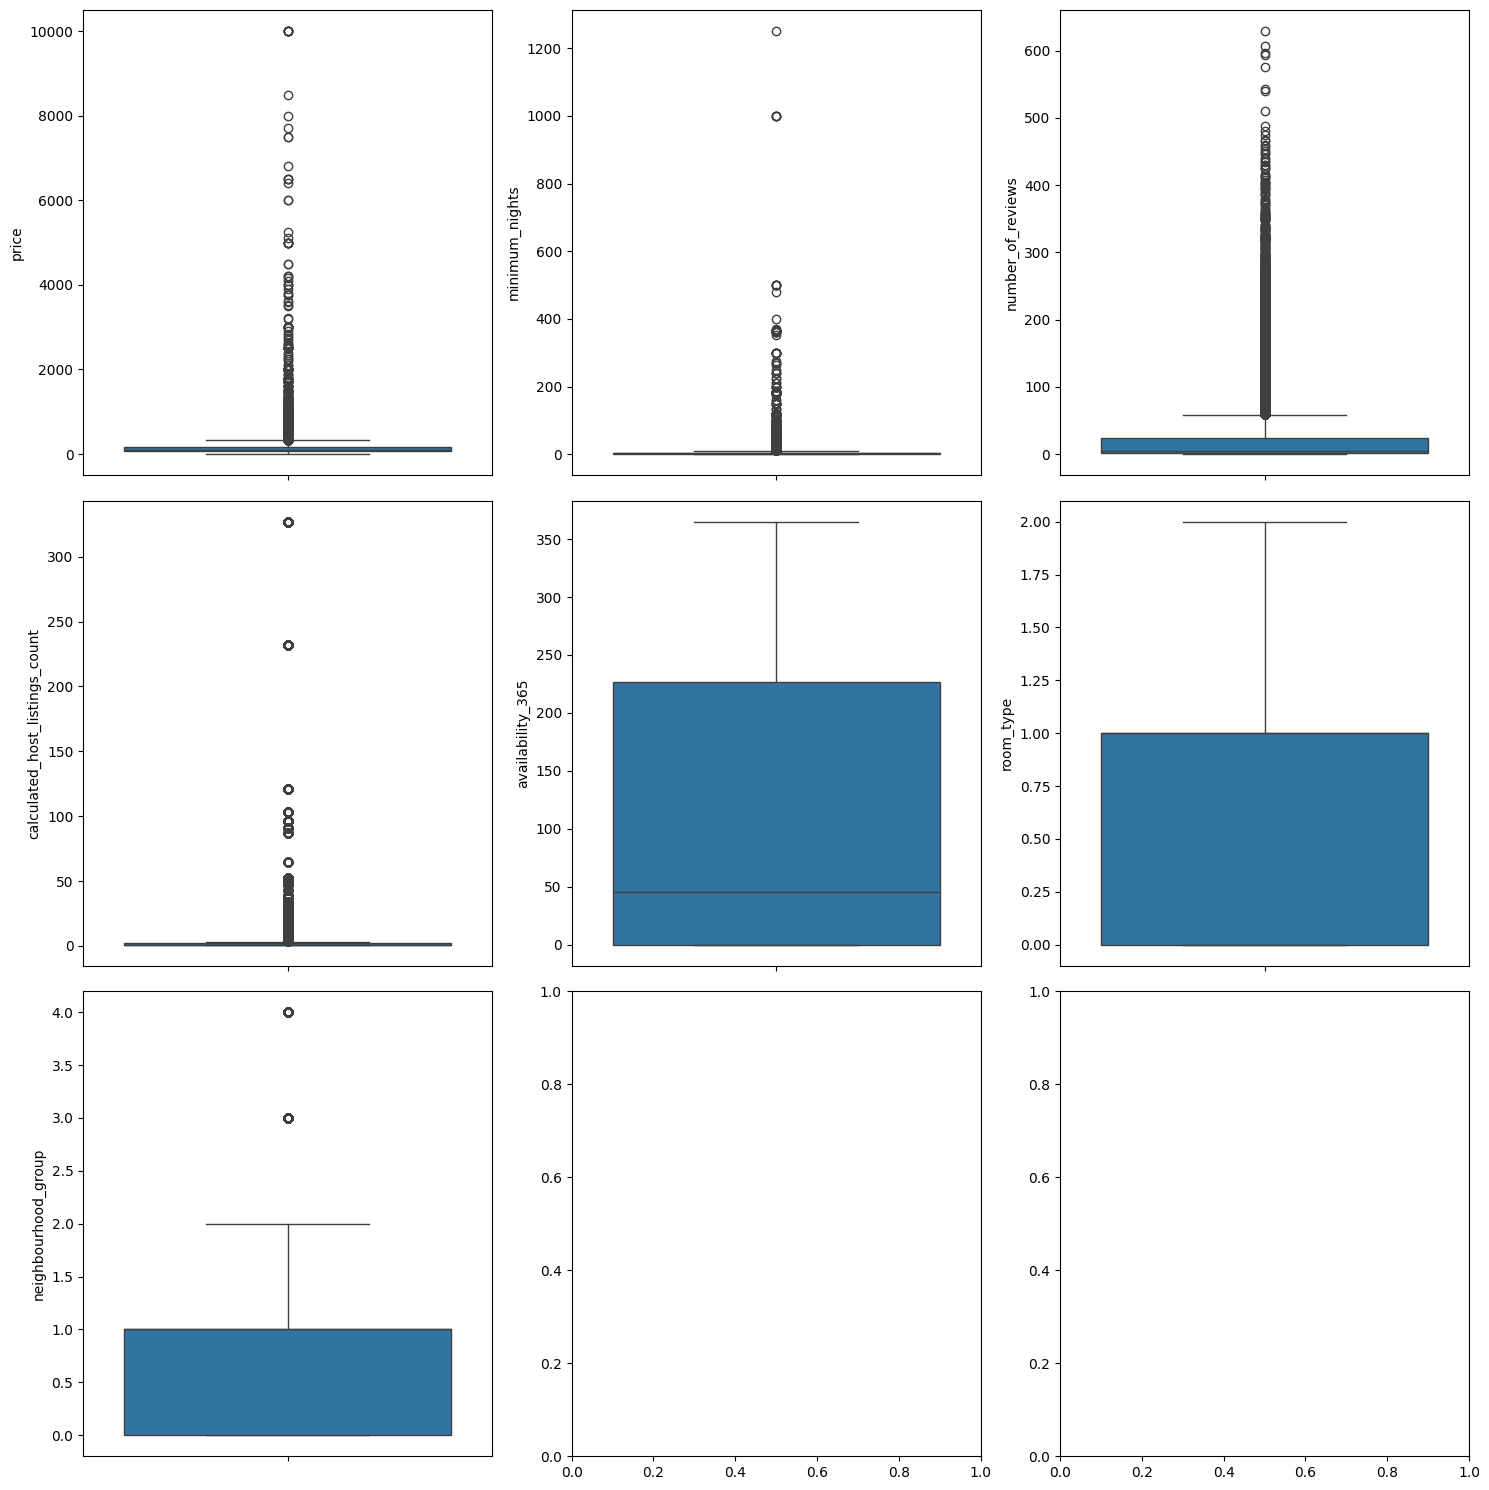

In [17]:
fig, axes = plt.subplots(3,3, figsize=(15,15))

sns.boxplot(ax=axes[0,0], data=total_data, y="price")
sns.boxplot(ax=axes[0,1], data=total_data, y="minimum_nights")
sns.boxplot(ax=axes[0,2], data=total_data, y="number_of_reviews")

sns.boxplot(ax=axes[1,0], data=total_data, y="calculated_host_listings_count")
sns.boxplot(ax=axes[1,1], data=total_data, y="availability_365")
sns.boxplot(ax=axes[1,2], data=total_data, y="room_type")

sns.boxplot(ax=axes[2,0], data=total_data, y="neighbourhood_group")

plt.tight_layout()
plt.show()

Los diagramas de caja permiten identificar valores extremos en diferentes variables del dataset.

### Detección de valores extremos en precio

In [18]:
price_stats = total_data["price"].describe()

price_iqr = price_stats["75%"] - price_stats["25%"]

upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print("Límite superior:", upper_limit)
print("Límite inferior:", lower_limit)

Límite superior: 334.0
Límite inferior: -90.0


In [19]:
total_data = total_data[total_data["price"] > 0]

Se eliminan registros con precio igual o menor a cero, ya que no representan alquileres reales.

### Detección de valores extremos en noches mínimas

In [20]:
nights_stats = total_data["minimum_nights"].describe()

nights_iqr = nights_stats["75%"] - nights_stats["25%"]

upper_limit = nights_stats["75%"] + 1.5 * nights_iqr
lower_limit = nights_stats["25%"] - 1.5 * nights_iqr

print("Límite superior:", upper_limit)
print("Límite inferior:", lower_limit)

Límite superior: 11.0
Límite inferior: -5.0


In [21]:
# limpiar valores extremos

total_data = total_data[total_data["minimum_nights"] <= 15]

Se eliminan registros con valores extremadamente altos de noches mínimas, ya que no representan el comportamiento habitual de reservas en Airbnb.

### Análisis de `calculated_host_listings_count`

In [22]:
host_stats = total_data["calculated_host_listings_count"].describe()

host_iqr = host_stats["75%"] - host_stats["25%"]

upper_limit = host_stats["75%"] + 1.5 * host_iqr
lower_limit = host_stats["25%"] - 1.5 * host_iqr

print("Límite superior:", upper_limit)
print("Límite inferior:", lower_limit)

Límite superior: 3.5
Límite inferior: -0.5


In [23]:
total_data = total_data[total_data["calculated_host_listings_count"] > 4]

Se eliminan registros con pocos anuncios por anfitrión para concentrar el análisis en hosts con mayor actividad.

In [24]:
total_data.isnull().sum().sort_values(ascending=False)

host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Escalado de variables

In [25]:
from sklearn.preprocessing import MinMaxScaler

num_variables = [
    "number_of_reviews",
    "minimum_nights",
    "calculated_host_listings_count",
    "availability_365",
    "neighbourhood_group",
    "room_type"
]

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(total_data[num_variables])

df_scal = pd.DataFrame(
    scaled_features,
    columns=num_variables,
    index=total_data.index
)

df_scal["price"] = total_data["price"]

df_scal.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
0,0.016575,0.000000,0.003106,1.000000,0.0,0.0,149
21,0.239411,0.071429,0.003106,0.950685,0.0,0.0,130
22,0.071823,0.000000,0.003106,0.997260,0.0,0.0,80
23,0.130755,0.071429,0.003106,0.832877,0.0,0.0,110
92,0.029466,0.428571,0.003106,0.506849,0.0,0.0,98


## Paso 6: Selección de variables

In [26]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

X = df_scal.drop("price", axis=1)
y = df_scal["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

selector = SelectKBest(score_func=chi2, k=4)

selector.fit(X_train, y_train)

selected_columns = X_train.columns[selector.get_support()]

X_train_sel = pd.DataFrame(
    selector.transform(X_train),
    columns=selected_columns
)

X_test_sel = pd.DataFrame(
    selector.transform(X_test),
    columns=selected_columns
)

X_train_sel.head()

,minimum_nights,calculated_host_listings_count,availability_365,room_type
0,0.000000,0.000000,0.846575,0.0
1,0.071429,1.000000,0.169863,0.5
2,0.071429,0.000000,1.000000,0.0
3,0.428571,0.130435,0.926027,0.0
4,0.071429,1.000000,0.778082,0.5


In [27]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)

import os

os.makedirs("data/processed", exist_ok=True)

X_train_sel.to_csv("data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("data/processed/clean_test.csv", index=False)

## Conclusiones 

Tras realizar el análisis exploratorio de los datos podemos destacar:

- Manhattan y Brooklyn concentran la mayoría de los alojamientos en Airbnb.
- El tipo de alojamiento más común es la vivienda completa.
- El precio presenta una distribución muy asimétrica con algunos valores extremadamente altos.
- No se observan correlaciones fuertes entre las variables numéricas analizadas.
- La mayoría de los alojamientos tienen pocas reseñas y requieren pocas noches mínimas.

Estos resultados permiten entender mejor la estructura del dataset y preparar los datos para futuros modelos de Machine Learning.